In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import os

# Model & preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

# Optional: LSTM
# from keras.models import Sequential
# from keras.layers import LSTM, Dense

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [3]:
import pandas as pd

# Step 1: Load the dataset
file_path = "household_power_consumption.txt"
df = pd.read_csv(file_path, sep=';', low_memory=False)

# Step 2: Replace '?' with NaN
df.replace('?', pd.NA, inplace=True)

# Step 3: Convert relevant columns to float
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 4: Create 'Datetime' column from 'Date' and 'Time'
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Step 5: Set 'Datetime' as the index
df.set_index('Datetime', inplace=True)

# Step 6: Drop original 'Date' and 'Time' columns
df.drop(columns=['Date', 'Time'], inplace=True)

# Step 7: Drop rows with missing values
df.dropna(inplace=True)

# Step 8: Final check
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2049280 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 125.1 MB
None
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00         

In [4]:
# Save the cleaned full dataset
df.to_csv("cleaned_power_data.csv")

In [5]:
import pandas as pd

df = pd.read_csv('cleaned_power_data.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])  # convert to datetime

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049280 entries, 0 to 2049279
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 125.1 MB


In [7]:
df_filled = df.fillna(method='ffill').fillna(method='bfill')

In [8]:
df_filled['Year'] = df_filled['Datetime'].dt.year
df_filled['Month'] = df_filled['Datetime'].dt.month
df_filled['Day'] = df_filled['Datetime'].dt.day
df_filled['Hour'] = df_filled['Datetime'].dt.hour
df_filled['Weekday'] = df_filled['Datetime'].dt.day_name()

In [9]:
df.isnull().sum()

Datetime                 0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

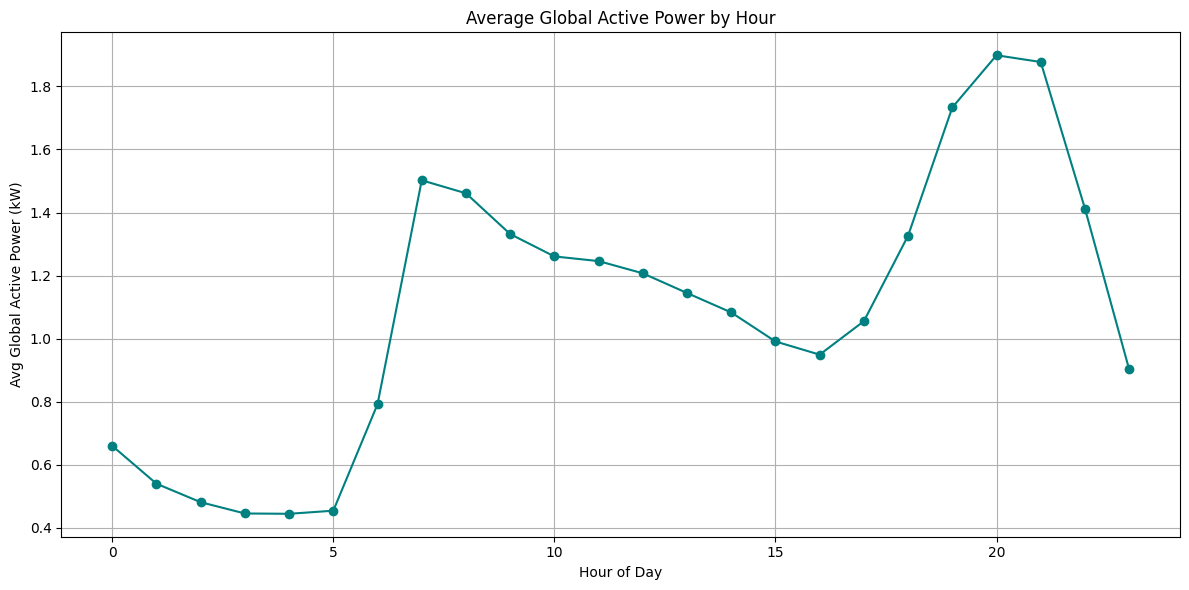

In [10]:
import matplotlib.pyplot as plt

hourly_avg = df_filled.groupby('Hour')['Global_active_power'].mean()

plt.figure(figsize=(12,6))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='teal')
plt.title('Average Global Active Power by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Global Active Power (kW)')
plt.grid(True)
plt.tight_layout()
plt.show()

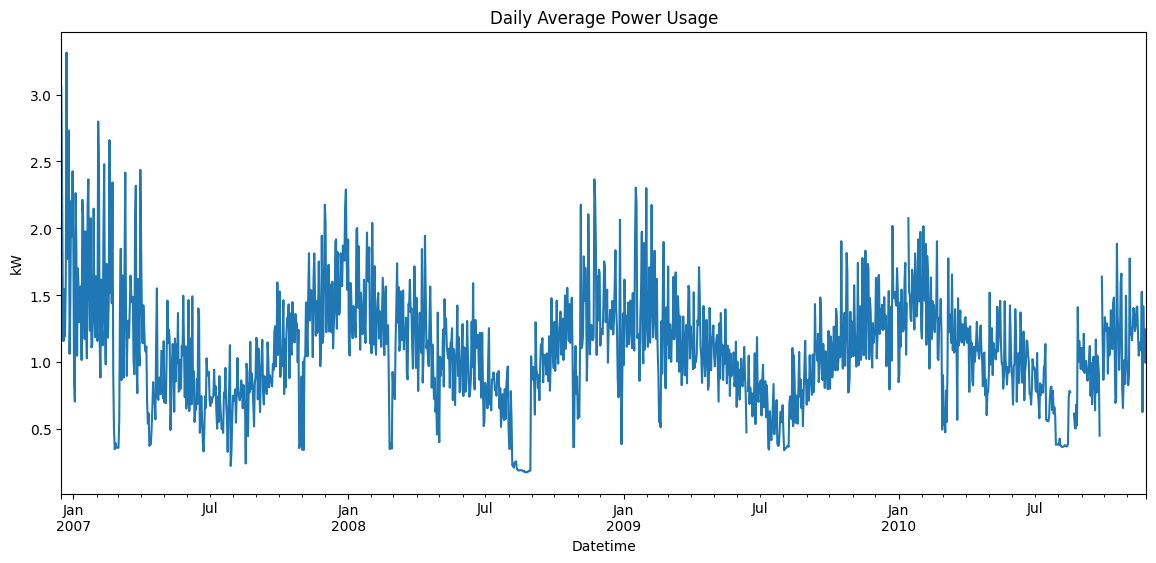

In [11]:
df_filled.set_index('Datetime')['Global_active_power'].resample('D').mean().plot(figsize=(14,6), title='Daily Average Power Usage', ylabel='kW')
plt.show()

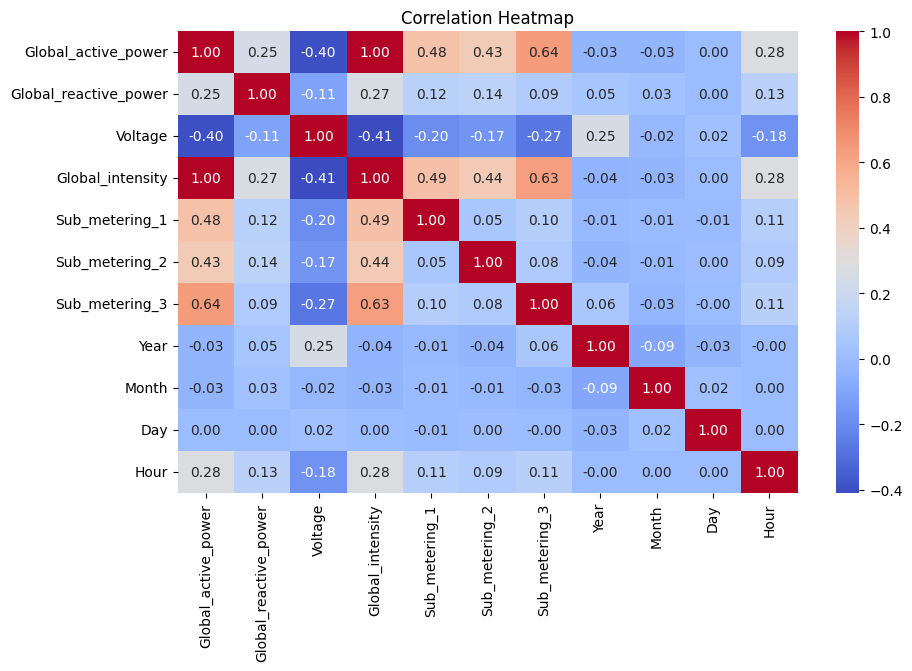

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df_filled.select_dtypes(include=[float, int])

# Plot the heatmap for numeric columns only
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


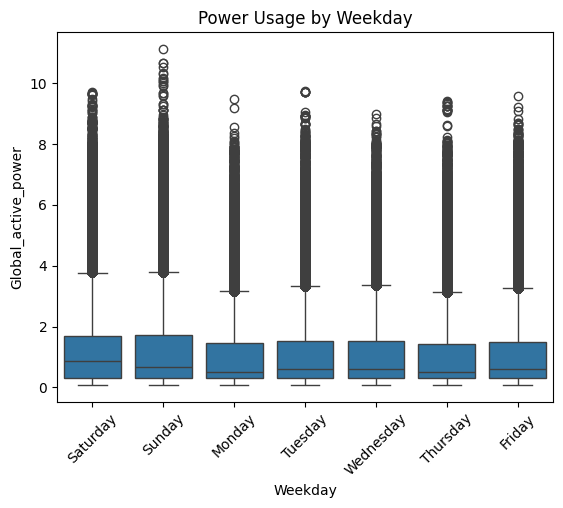

In [13]:
sns.boxplot(x='Weekday', y='Global_active_power', data=df_filled)
plt.xticks(rotation=45)
plt.title('Power Usage by Weekday')
plt.show()

In [2]:
import pandas as pd

df = pd.read_csv("cleaned_power_data.csv")  
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.dtypes)
df.head()

Shape: (2049280, 8)
Columns: ['Datetime', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Datetime                  object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df.isnull().sum()

Datetime                 0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [4]:
df_cleaned = df.dropna()
print("New shape after dropna:", df_cleaned.shape)

New shape after dropna: (2049280, 8)


In [5]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [6]:
df.describe(include='object')

,Datetime
count,2049280
unique,2049280
top,2010-11-26 20:46:00
freq,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049280 entries, 0 to 2049279
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Datetime               object 
 1   Global_active_power    float64
 2   Global_reactive_power  float64
 3   Voltage                float64
 4   Global_intensity       float64
 5   Sub_metering_1         float64
 6   Sub_metering_2         float64
 7   Sub_metering_3         float64
dtypes: float64(7), object(1)
memory usage: 125.1+ MB


In [8]:
for col in df.select_dtypes(include='object'):
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Datetime ---
Datetime
2010-11-26 20:46:00    1
2010-11-26 20:45:00    1
2010-11-26 20:44:00    1
2010-11-26 20:43:00    1
2010-11-26 20:42:00    1
                      ..
2006-12-16 17:28:00    1
2006-12-16 17:27:00    1
2006-12-16 17:26:00    1
2006-12-16 17:25:00    1
2006-12-16 17:24:00    1
Name: count, Length: 2049280, dtype: int64



In [9]:
import numpy as np  # Make sure this line is included

# Select only numeric columns
numeric_data = df.select_dtypes(include=[np.number])

# Skewness and Kurtosis
print("Skewness:\n", numeric_data.skew())
print("\nKurtosis:\n", numeric_data.kurt())

Skewness:
 Global_active_power      1.786233
Global_reactive_power    1.261914
Voltage                 -0.326665
Global_intensity         1.849100
Sub_metering_1           5.944541
Sub_metering_2           7.090553
Sub_metering_3           0.724688
dtype: float64

Kurtosis:
 Global_active_power       4.218685
Global_reactive_power     2.605633
Voltage                   0.724707
Global_intensity          4.601243
Sub_metering_1           35.642993
Sub_metering_2           57.907344
Sub_metering_3           -1.282198
dtype: float64


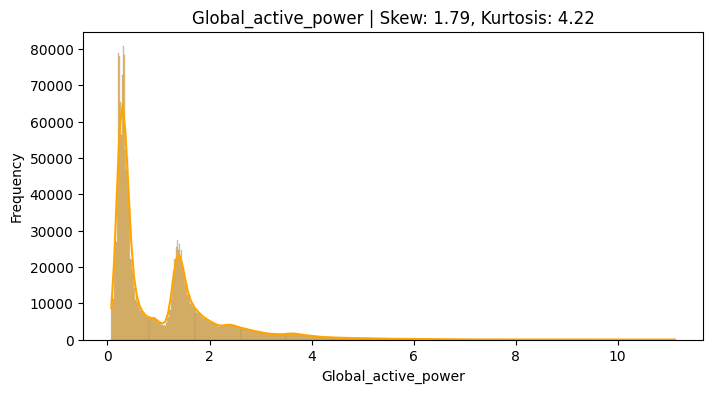

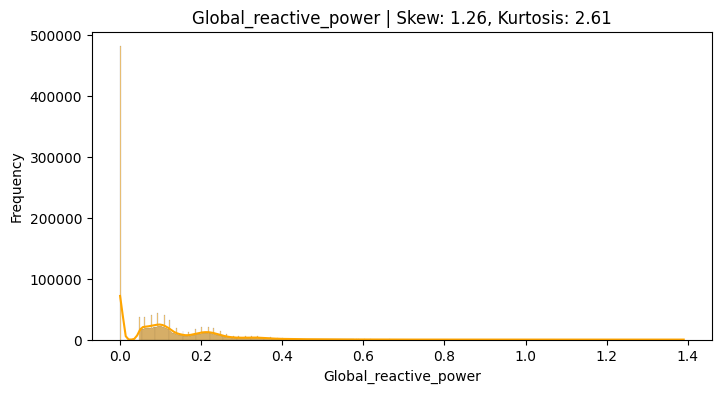

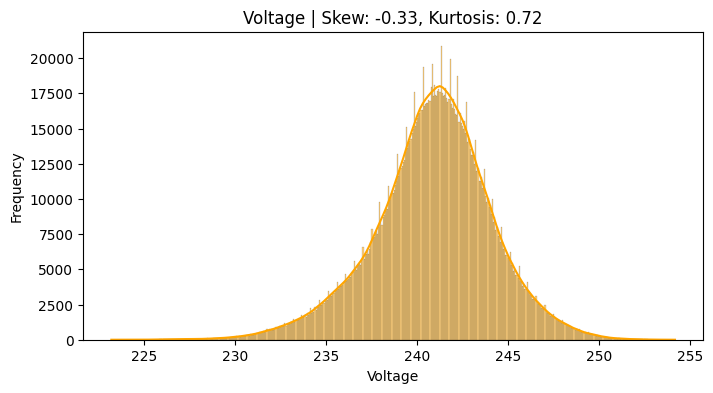

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
features = ['Global_active_power', 'Global_reactive_power', 'Voltage']

for feature in features:
    plt.figure(figsize=(8,4))
    sns.histplot(df[feature], kde=True, color='orange')
    plt.title(f'{feature} | Skew: {df[feature].skew():.2f}, Kurtosis: {df[feature].kurt():.2f}')
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

In [11]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)]
    return outliers

for col in df.select_dtypes(include=['float64', 'int64']):
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

Global_active_power: 94907 outliers
Global_reactive_power: 40420 outliers
Voltage: 51067 outliers
Global_intensity: 100961 outliers
Sub_metering_1: 169105 outliers
Sub_metering_2: 77151 outliers
Sub_metering_3: 0 outliers


In [12]:
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

                       Global_active_power  Global_reactive_power   Voltage  \
Global_active_power               1.000000               0.247017 -0.399762   
Global_reactive_power             0.247017               1.000000 -0.112246   
Voltage                          -0.399762              -0.112246  1.000000   
Global_intensity                  0.998889               0.266120 -0.411363   
Sub_metering_1                    0.484401               0.123111 -0.195976   
Sub_metering_2                    0.434569               0.139231 -0.167405   
Sub_metering_3                    0.638555               0.089617 -0.268172   

                       Global_intensity  Sub_metering_1  Sub_metering_2  \
Global_active_power            0.998889        0.484401        0.434569   
Global_reactive_power          0.266120        0.123111        0.139231   
Voltage                       -0.411363       -0.195976       -0.167405   
Global_intensity               1.000000        0.489298        0.44

In [13]:
df

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
2049275,2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2049276,2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2049277,2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2049278,2010-11-26 21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [24]:
import pandas as pd
df=pd.read_csv("cleaned_power_data.csv")

In [25]:
from sklearn.model_selection import train_test_split

# Convert Datetime column to datetime format and extract time-based features
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.day
df['month'] = df['Datetime'].dt.month
df['weekday'] = df['Datetime'].dt.weekday

# Drop the original Datetime column
df.drop(columns=['Datetime'], inplace=True)

# Define target and features
target = 'Global_active_power'
X = df.drop(columns=[target])
y = df[target]

# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1639424, 10), (409856, 10), (1639424,), (409856,))

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Predict
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)

# Evaluate models
def evaluate_model(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred)
    }

print("Linear Regression:", evaluate_model(y_test, lr_preds))
print("Random Forest:", evaluate_model(y_test, rf_preds))
print("Gradient Boosting:", evaluate_model(y_test, gb_preds))


Linear Regression: {'RMSE': np.float64(0.04025152735890621), 'MAE': 0.02574831272523486, 'R²': 0.9985584813820256}
Random Forest: {'RMSE': np.float64(0.025388279683186864), 'MAE': 0.01171807755637739, 'R²': 0.9994265149843868}
Gradient Boosting: {'RMSE': np.float64(0.03375969630025007), 'MAE': 0.02104844347425499, 'R²': 0.9989859658313531}


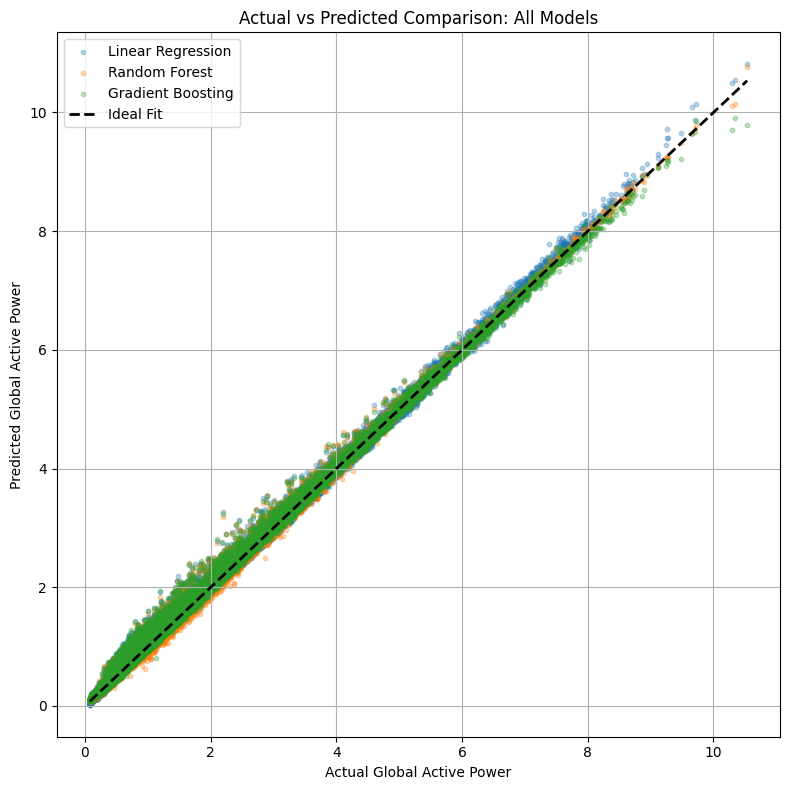

In [28]:
plt.figure(figsize=(8, 8))

# Plot actual vs predicted for each model
plt.scatter(y_test, lr_preds, alpha=0.3, label='Linear Regression', s=10)
plt.scatter(y_test, rf_preds, alpha=0.3, label='Random Forest', s=10)
plt.scatter(y_test, gb_preds, alpha=0.3, label='Gradient Boosting', s=10)

# Ideal line: predicted = actual
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')

plt.xlabel('Actual Global Active Power')
plt.ylabel('Predicted Global Active Power')
plt.title('Actual vs Predicted Comparison: All Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



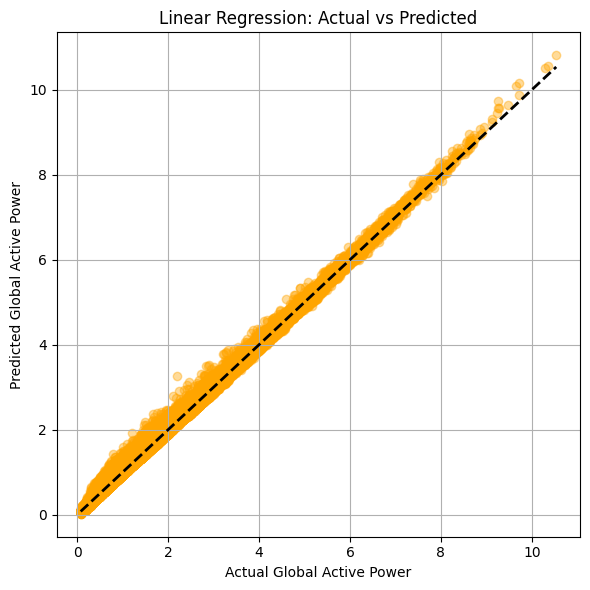

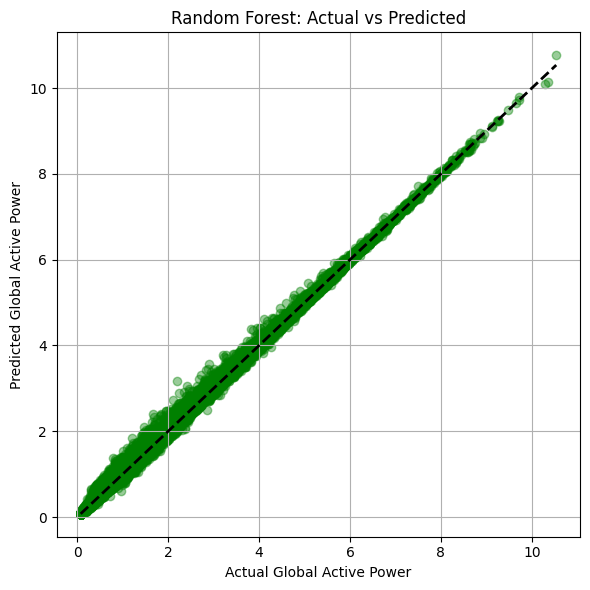

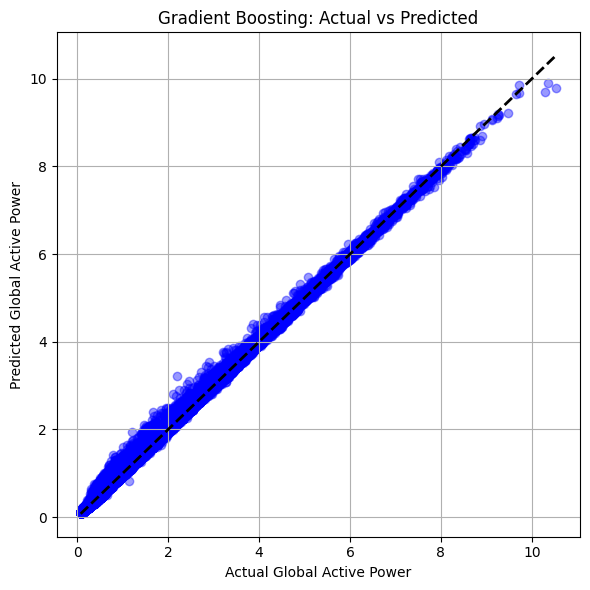

In [29]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, lr_preds, alpha=0.4, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Global Active Power')
plt.ylabel('Predicted Global Active Power')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_preds, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Global Active Power')
plt.ylabel('Predicted Global Active Power')
plt.title('Random Forest: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, gb_preds, alpha=0.4, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Global Active Power')
plt.ylabel('Predicted Global Active Power')
plt.title('Gradient Boosting: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()



In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define evaluation function
def evaluate_model(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred)
    }

# Hyperparameter grid
rf_param_grid = {
    'n_estimators': [5, 10],
    'max_depth': [2, 4, None],
}

# GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit and find best model
rf_grid_search.fit(X_train, y_train)
best_rf_model = rf_grid_search.best_estimator_
best_rf_preds = best_rf_model.predict(X_test)
best_rf_metrics = evaluate_model(y_test, best_rf_preds)

print("Best Parameters:", rf_grid_search.best_params_)
print("Evaluation Metrics:", best_rf_metrics)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'max_depth': None, 'n_estimators': 10}
Evaluation Metrics: {'RMSE': np.float64(0.02669323768497157), 'MAE': 0.012438406233889036, 'R²': 0.999366045580072}
